In this script, I visualize and analyze the behavior of the Q-learning-rule v.s. Q-learning-rule scenario from recorded history.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
DATA_DIR = "./data/CIST"  # or update to your actual path
PREFIX = "q-learning-rule-vs-q-learning-rule-price-competition"
ACTION_SUFFIX = "-action.csv"
FIGURE_DIR = "./figure/CIST"

In [33]:
df_action_hist = pd.read_csv('data/q-learning-dummy-rule-vs-q-learning-dummy-rule-price-competition-action.csv')
df_action_hist.head()

,Run 1,Run 2,Run 3,Run 4,Run 5,Run 6,Run 7,Run 8,Run 9,Run 10,...,Run 41,Run 42,Run 43,Run 44,Run 45,Run 46,Run 47,Run 48,Run 49,Run 50
0,0.0,1.0,0.0,2.0,0.0,2.0,1.0,0.0,1.0,3.0,...,3.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
1,0.0,1.0,0.0,2.0,0.0,2.0,1.0,0.0,1.0,3.0,...,3.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
2,0.0,1.0,0.0,2.0,0.0,2.0,1.0,0.0,1.0,3.0,...,3.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
3,0.0,1.0,0.0,2.0,0.0,2.0,1.0,0.0,1.0,3.0,...,3.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
4,0.0,1.0,0.0,2.0,0.0,2.0,1.0,0.0,1.0,3.0,...,3.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0


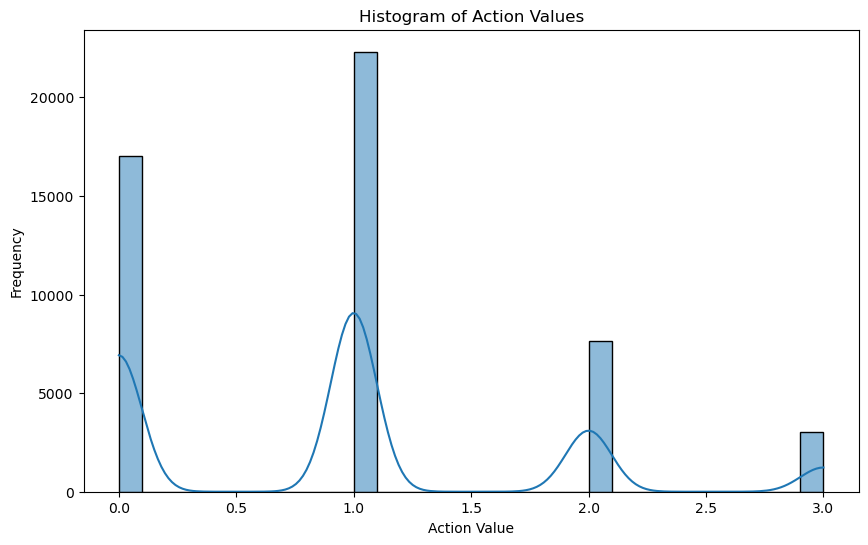

In [34]:
# histogram all the numbers in the dataframe
all_values = df_action_hist.values.flatten()
plt.figure(figsize=(10, 6))
sns.histplot(all_values, bins=30, kde=True)
plt.title('Histogram of Action Values')
plt.xlabel('Action Value')
plt.ylabel('Frequency')
plt.show()

In [35]:

def list_action_files(directory, prefix, suffix):
    """List all action files with proper sorting."""
    return sorted(
        [f for f in os.listdir(directory) if f.startswith(prefix) and f.endswith(suffix)]
    )

def plot_histogram_for_file(filepath, title, save_path=None):
    """Plot a density histogram for flattened action data from a file."""
    df = pd.read_csv(filepath)
    actions = df.values.flatten()
    plt.figure(figsize=(6, 4))
    plt.hist(actions, bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], edgecolor='black', align='mid', density=True)
    plt.xticks([0, 1, 2, 3])
    plt.xlabel("Rule Index")
    plt.ylabel("Density")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

Processing Histogram of Actions. Period 0...


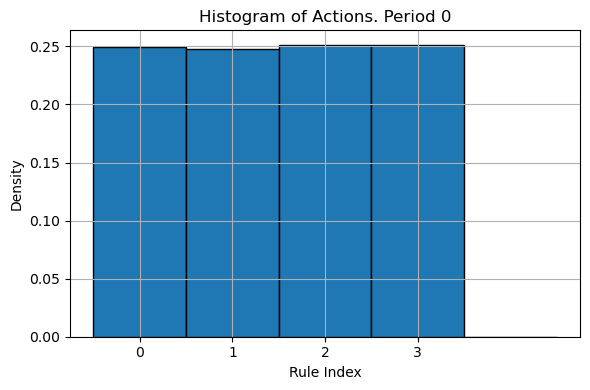

Processing Histogram of Actions. Period 20000...


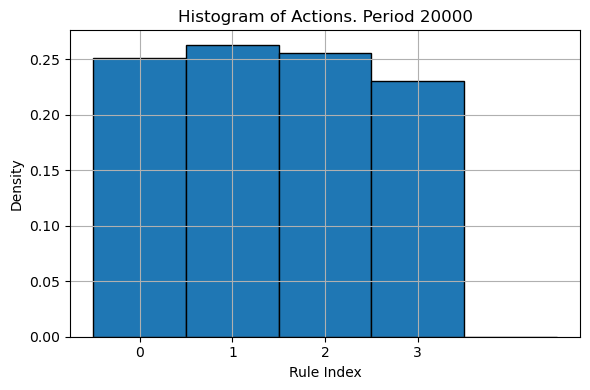

Processing Histogram of Actions. Period 40000...


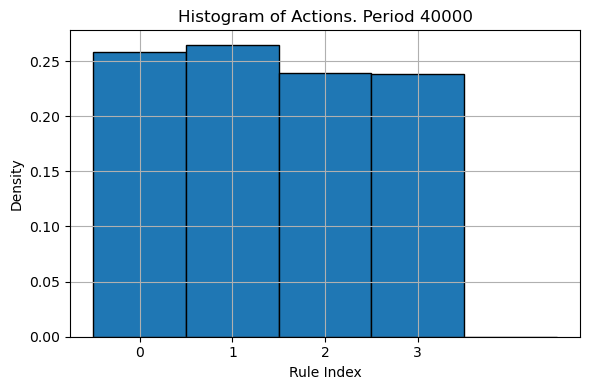

Processing Histogram of Actions. Period 60000...


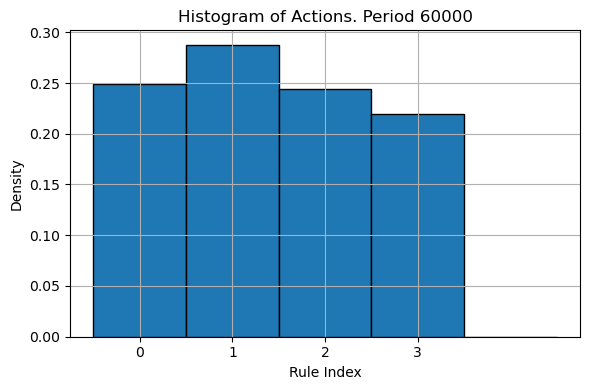

Processing Histogram of Actions. Period 80000...


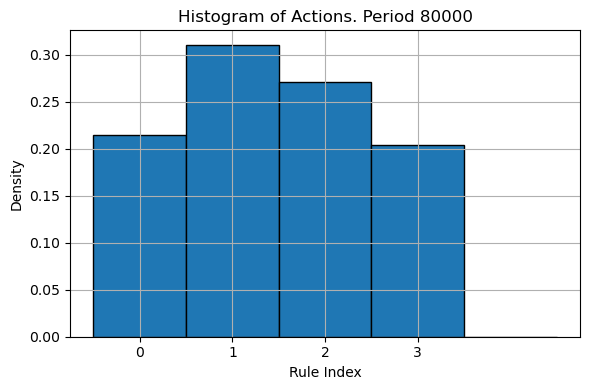

Processing Histogram of Actions. Period 100000...


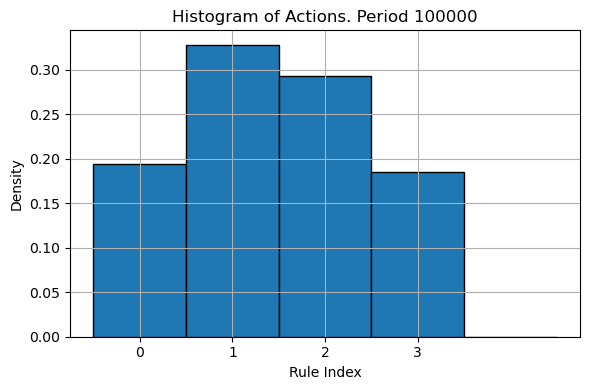

Processing Histogram of Actions. Period 120000...


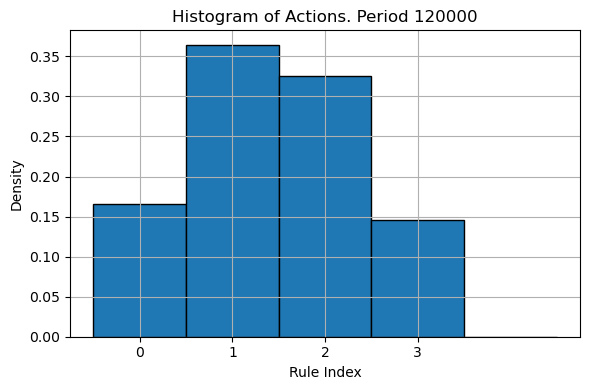

Processing Histogram of Actions. Period 140000...


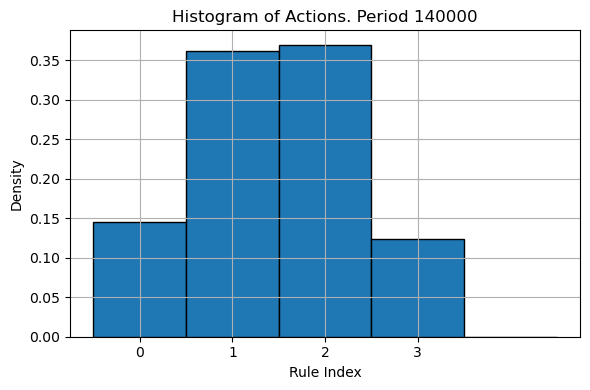

Processing Histogram of Actions. Period 160000...


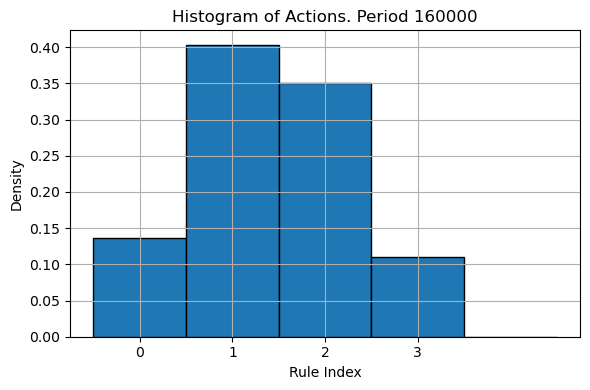

Processing Histogram of Actions. Period 180000...


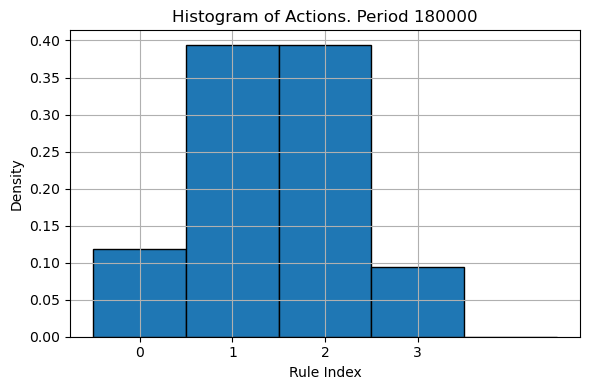

In [36]:
# plot the first
files = list_action_files(DATA_DIR, PREFIX, ACTION_SUFFIX)
for fname in files:
    filepath = os.path.join(DATA_DIR, fname)
    period_label = fname.replace(PREFIX, "").replace(ACTION_SUFFIX, "")
    period_number = int(period_label[2:])
    title = f"Histogram of Actions. Period {period_number}"
    if period_number % 20000 == 0:
        print(f"Processing {title}...")
        save_path = os.path.join(FIGURE_DIR, f"CIST_histogram_{period_number}.png")
        plot_histogram_for_file(filepath, title, save_path=save_path)